In [1]:
import os
import h5py
from temporaldata import Data

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [2]:
BIDS_ROOT = (
    "/network/projects/neuro-galaxy/data/processed/neurosoft_minipigs_2026"
)
H5_FILENAME = "sub-02_ses-01_task-AcousticStim_desc-filtered_LH.h5"

### 1. Load .h5 file

In [3]:
with h5py.File(os.path.join(BIDS_ROOT, H5_FILENAME), "r") as f:
    data = Data.from_hdf5(f, lazy=False)

    print("Fields in data:")
    for key in data.keys():
        print("   - ", key)

Fields in data:
   -  acoustic_stim_trials
   -  brainset
   -  channels
   -  device
   -  ecog
   -  on_vs_off_trials
   -  session
   -  splits
   -  subject


### 2. Channels info

In [4]:
print("Channel names: ", data.channels.id)
print("Channel types: ", data.channels.type)

Channel names:  ['SG1D1E1' 'SG1D1E2' 'SG1D1E3' 'SG1D1E4' 'SG1D1E5' 'SG1D1E6' 'SG1D1E7'
 'SG1D1E8' 'SG1D1E9' 'SG1D1E10' 'SG1D1E11' 'SG1D1E12' 'SG1D1E13'
 'SG1D1E14' 'SG1D1E15' 'SG1D1E16' 'SG1D1E17' 'SG1D1E18' 'SG1D1E19'
 'SG1D1E20' 'SG1D1E21' 'SG1D1E22' 'SG1D1E23' 'SG1D1E24' 'N/A-6' 'N/A-7'
 'N/A-15' 'N/A-16' 'N/A-18' 'N/A-19' 'N/A-26' 'N/A-27']
Channel types:  ['ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog'
 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog'
 'ecog' 'ecog' 'ecog' 'ecog' 'misc' 'misc' 'misc' 'misc' 'misc' 'misc'
 'misc' 'misc']


### 3. iEEG data visualization

In [5]:
def plot_ieeg_signal(
    ieeg_signal,
    ch_names,
    ch_types,
    sampling_rate=None,
    interval=None,
    start_time=None,
    end_time=None,
    timestamps=None,
    gap_threshold=None,
    actual_gap_width=True,
    gap_display_width=10.0,
    figsize=(15, 8),
):
    """
    Plots iEEG signal (stacked channels, black) with shaded interval regions indicating different labeled intervals.
    Supports both regular and irregular timeseries. For irregular timeseries with gaps, renders gaps as grey shaded areas.

    Args:
        ieeg_signal: n_channels x n_times or n_times x n_channels. Will transpose if needed.
        ch_names (list): Channel names.
        ch_types (list): Channel types (must match ch_names).
        sampling_rate (float, optional): Sampling rate in Hz. Required if timestamps is None.
        interval (Interval, optional): Interval object with start, end, and behavior_labels.
        start_time (float, optional): Start time for plotting window in seconds. Defaults to 0.
        end_time (float, optional): End time for plotting window in seconds. Defaults to end of signal.
        timestamps (array, optional): Explicit timestamps for each sample. If provided, used instead of sampling_rate.
        gap_threshold (float, optional): Threshold in seconds for detecting gaps. If None, auto-detected as 2 * median inter-sample interval.
        actual_gap_width (bool, optional): If True, gaps are displayed with their actual duration. If False, gaps are displayed with a constant width. Defaults to True.
        gap_display_width (float, optional): Width in seconds for gap display when actual_gap_width=False. Defaults to 10.0 seconds.
        figsize (tuple): Figure size.
    """
    # Auto transpose to channels x time
    if ieeg_signal.shape[0] == len(ch_names):
        ecog_signal = ieeg_signal
    else:
        ecog_signal = ieeg_signal.T

    is_ecog = np.array(
        [
            typ.lower() in ("ecog", "ieeg", "ecogv", "ecog_hgrid")
            for typ in ch_types
        ]
    )
    ch_names_used = np.array(ch_names)[is_ecog]
    ecog_signal = ecog_signal[is_ecog, :]
    n_channels = len(ch_names_used)
    n_samples = ecog_signal.shape[1]

    # Generate or use provided timestamps
    if timestamps is not None:
        t = np.asarray(timestamps).ravel()
        assert len(t) == n_samples, (
            f"timestamps length ({len(t)}) must match signal time dimension ({n_samples})"
        )
    else:
        if sampling_rate is None:
            raise ValueError(
                "Either sampling_rate or timestamps must be provided"
            )
        t = np.arange(n_samples) / sampling_rate

    # Handle time window filtering
    if start_time is None:
        start_time = 0

    idx = t >= start_time
    if end_time is not None:
        idx = idx & (t <= end_time)
    t = t[idx]
    ecog_signal = ecog_signal[:, idx]

    fig, ax = plt.subplots(figsize=figsize)
    offset = 5 * np.nanstd(ecog_signal)

    # Draw gaps first (lower z-order) if we have irregular timestamps
    legend_handles = {}
    t_display = (
        t.copy()
    )  # Display time (may be compressed if actual_gap_width=False)
    gap_mask = None

    if timestamps is not None:
        # Detect gaps in the irregular timeseries
        diffs = np.diff(t)
        if len(diffs) > 0:
            typical_interval = np.median(diffs)
            if gap_threshold is None:
                gap_threshold = max(2 * typical_interval, 1e-6)

            gap_indices = np.where(diffs > gap_threshold)[0]
            if len(gap_indices) > 0:
                # Create mask of indices NOT in gaps (for signal plotting)
                gap_mask = np.ones(len(t), dtype=bool)
                for gap_idx in gap_indices:
                    gap_start = t[gap_idx]
                    gap_end = t[gap_idx + 1]
                    # Exclude both the boundary and any points strictly within the gap
                    gap_mask &= ~((t >= gap_start) & (t <= gap_end))

                # If not using actual gap width, create a compressed time axis
                if not actual_gap_width:
                    t_display = np.zeros_like(t)
                    current_display_time = t[0]
                    for i in range(len(t)):
                        if i == 0:
                            t_display[i] = current_display_time
                        else:
                            time_diff = t[i] - t[i - 1]
                            is_gap = time_diff > gap_threshold
                            if is_gap:
                                current_display_time += gap_display_width
                            else:
                                current_display_time += time_diff
                            t_display[i] = current_display_time

                # Draw grey spans for gaps
                for gap_idx in gap_indices:
                    gap_start_idx = gap_idx
                    gap_end_idx = gap_idx + 1
                    gap_start_display = t_display[gap_start_idx]
                    gap_end_display = t_display[gap_end_idx]

                    if actual_gap_width:
                        # Use actual gap duration
                        ax.axvspan(
                            gap_start_display,
                            gap_end_display,
                            color="grey",
                            alpha=0.25,
                            lw=0,
                            zorder=0,
                        )
                    else:
                        # Use constant display width, centered on gap midpoint
                        gap_midpoint_display = (
                            gap_start_display + gap_end_display
                        ) / 2
                        half_width = gap_display_width / 2
                        ax.axvspan(
                            gap_midpoint_display - half_width,
                            gap_midpoint_display + half_width,
                            color="grey",
                            alpha=0.25,
                            lw=0,
                            zorder=0,
                        )

                # Add gap to legend (once)
                legend_handles["gap"] = Patch(
                    facecolor="grey", alpha=0.25, label="gap", edgecolor="none"
                )

    # Plot signal traces, skipping gap regions
    for ch_idx, ch_name in enumerate(ch_names_used):
        sig = ecog_signal[ch_idx].copy().astype(float)
        if gap_mask is not None:
            # Insert NaN values where gaps occur to break the line
            sig[~gap_mask] = np.nan
        ax.plot(
            t_display,
            sig + ch_idx * offset,
            color="black",
            zorder=1,
            linewidth=0.5,
        )

    ax.set_yticks(offset * np.arange(n_channels))
    ax.set_yticklabels(ch_names_used)
    ax.set_xlabel("Time (s)")
    ax.set_title("ECoG iEEG Signal with Intervals")
    ax.grid(True, axis="x", linestyle=":")

    # If using compressed time axis, map tick labels from display time to actual time
    if timestamps is not None and not actual_gap_width:
        xticks_display = ax.get_xticks()
        xticks_actual = np.interp(xticks_display, t_display, t)
        ax.set_xticklabels([f"{val:.1f}" for val in xticks_actual])

    if interval is not None:
        # Prepare intervals for coloring and legend
        interval_starts = np.array(interval.start)
        interval_ends = np.array(interval.end)
        interval_labels = np.array(interval.behavior_labels)
        n_intervals = len(interval_starts)

        # Assign distinct colors to unique labels using matplotlib tab10 palette (or fallback)
        unique_labels = np.unique(interval_labels)
        color_map = {}
        cmap = plt.get_cmap("tab10")
        for i, lbl in enumerate(unique_labels):
            color_map[lbl] = cmap(i % 10)

        interval_handles = {}

        for i in range(n_intervals):
            s = interval_starts[i]  # start time in seconds
            e = interval_ends[i]  # end time in seconds
            lbl = interval_labels[i]
            # Skip intervals outside the time window
            if end_time is not None and s > end_time:
                continue
            if e < start_time:
                continue

            # Clip interval to the time window
            s = max(s, start_time)
            e = min(e, end_time) if end_time is not None else e

            # Map actual times to display times
            s_display = np.interp(s, t, t_display)
            e_display = np.interp(e, t, t_display)

            shade_color = color_map[lbl]
            # vertical span over all traces (x-axis represents time in seconds)
            # Only add label to legend once
            legend_label = (
                str(lbl) if interval_handles.get(lbl) is None else None
            )
            ax.axvspan(
                s_display,
                e_display,
                color=shade_color,
                alpha=0.18,
                lw=0,
                label=legend_label,
                zorder=2,
            )
            # Register legend handle if not already present
            if legend_label is not None:
                interval_handles[lbl] = Patch(
                    facecolor=shade_color,
                    alpha=0.18,
                    label=legend_label,
                    edgecolor="none",
                )

        # Merge interval and gap handles
        legend_handles.update(interval_handles)

    # Draw the legend (only if there are labels)
    if legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Annotations",
            loc="best",
            bbox_to_anchor=(1, 1),
        )

    plt.tight_layout()
    plt.show()

In [6]:
# Example usage (uncomment to run):
signal = data.ecog.signal
ch_names = data.channels.id
ch_types = data.channels.type
# For IrregularTimeSeries, use timestamps directly (no sampling_rate attribute)
timestamps = data.ecog.timestamps

# Trials
on_vs_off_trials = data.on_vs_off_trials
acoustic_stim_trials = data.acoustic_stim_trials

n_times, n_channels = signal.shape
recording_time = data.ecog.domain.end[0]
print("recording time: ", recording_time, "seconds")
print("n_channels: ", n_channels)

recording time:  12735.5995 seconds
n_channels:  32


In [7]:
start_time = 2000  # seconds
end_time = 5000  # seconds

#### On (stim) vs Off (no stim) Task 

/tmp/ipykernel_979070/1729199144.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{val:.1f}' for val in xticks_actual])


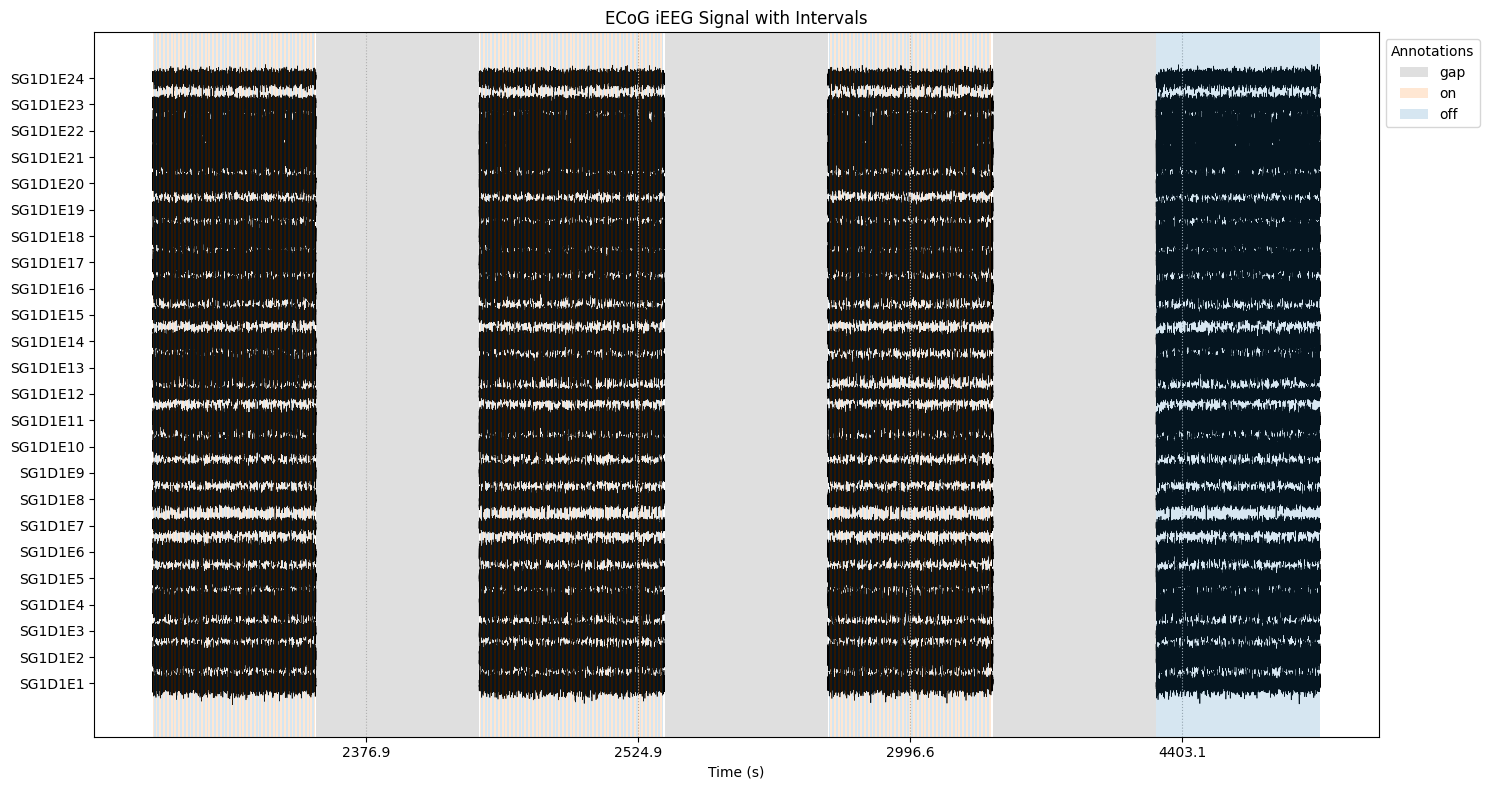

In [8]:
plot_ieeg_signal(
    signal.T,
    ch_names,
    ch_types,
    timestamps=timestamps,
    interval=on_vs_off_trials,
    start_time=start_time,
    end_time=end_time,
    actual_gap_width=False,
    gap_display_width=120.0,
    figsize=(15, 8),
)

#### Acoustic Stimulation Task 

/tmp/ipykernel_979070/1729199144.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{val:.1f}' for val in xticks_actual])


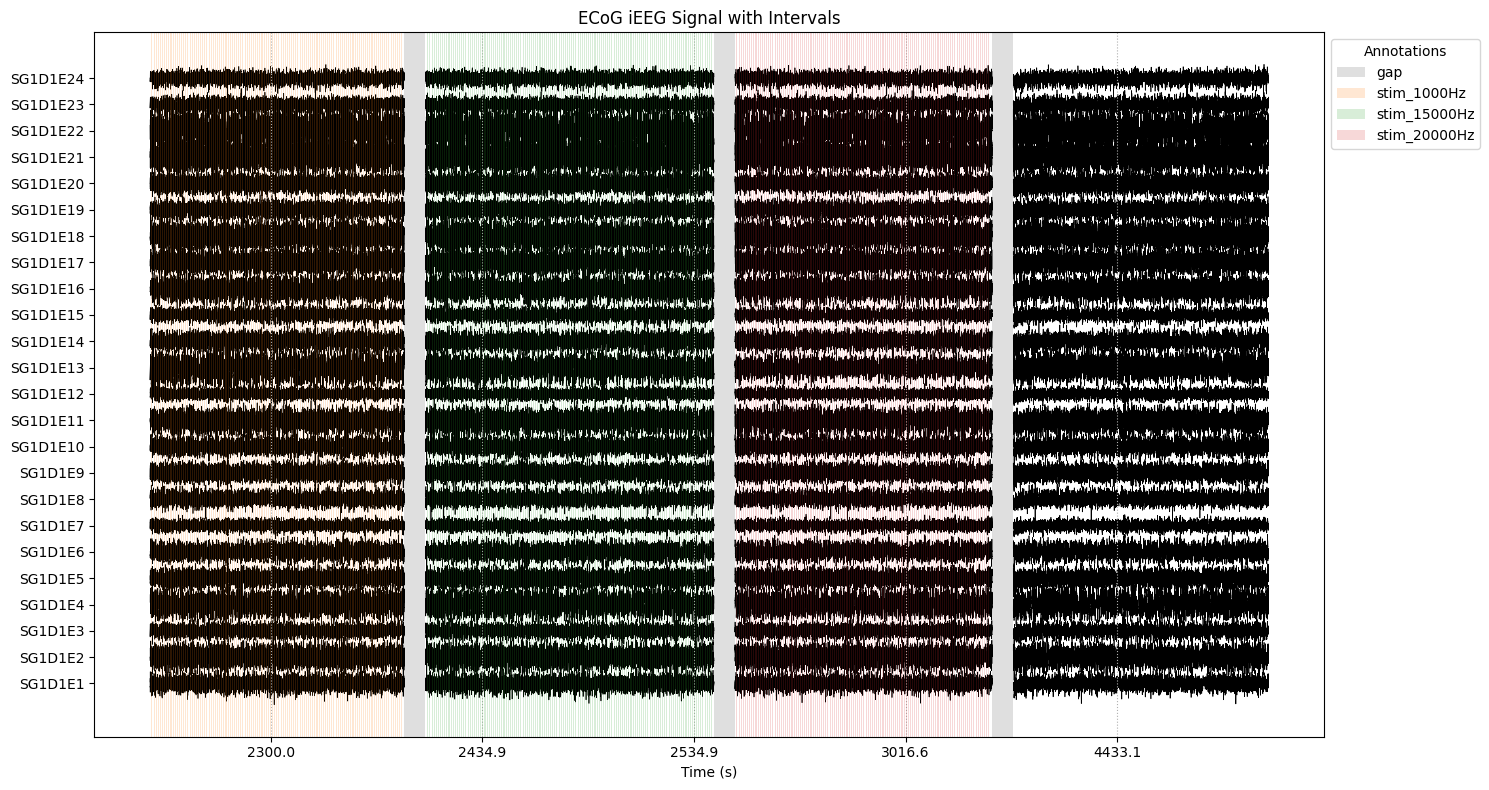

In [9]:
plot_ieeg_signal(
    signal.T,
    ch_names,
    ch_types,
    timestamps=timestamps,
    interval=acoustic_stim_trials,
    start_time=start_time,
    end_time=end_time,
    actual_gap_width=False,
    figsize=(15, 8),
)